# 18_geo_fno_train_v1.ipynb

FNO с **geometry-conditioned lift** вместо bilinear-апсемплинга.

## Чем отличается от 16_fno_train
В `16` входной тензор `(2, 16, 256)` поднимается в image-domain через
`F.interpolate(..., mode="bilinear")` до `(2, 192, 192)`, потом конкатенируется с
координатной сеткой `(gy, gx)` и подаётся в FNO. Bilinear-лифт геометрически
бессмысленный: соседство по индексу приёмника (256-я ось) — это соседство по углу
на кольце, и растягивание этого в `(192, 192)`-картинку через bilinear создаёт
фейковую структуру.

Здесь bilinear-лифт заменён на **точно ту же цепочку**, что и в
`14_geo_unet_train_v1`: per-token MLP → scatter в физические пиксельные позиции
приёмников → spreader (2 conv 7×7). Спектральная часть FNO остаётся неизменной.

## Структура модели
```
(B, 2, 16, 256) + geometry tensors
   ↓ GeometryConditionedBranch
(B, 16, 256, embed_dim)
   ↓ GeometryAwareLift (sum over S, scatter to rcv positions)
(B, embed_dim, 192, 192)              [sparse, ~256 non-zero pixels]
   ↓ Spreader (2 conv 7x7)
(B, embed_dim, 192, 192)              [dense]
   ↓ concat with grid coords (gy, gx)
(B, embed_dim+2, 192, 192)
   ↓ input_proj 1x1 conv
(B, fno_width, 192, 192)
   ↓ Spectral blocks (unchanged from 16)
(B, fno_width, 192, 192)
   ↓ head 1x1 conv
(B, 1, 192, 192)                       [linear output, target in [-1, 1]]
```

## Замечания

**Зачем нужен Spreader для FNO.** Спектральная свёртка работает с низкими модами
(modes=24×24 из 192×97 после rfft2). После scatter ненули стоят только в ~256
пикселях из 36864 — это «delta-like» сигнал, у которого почти вся энергия в
**высоких** частотах. Без spreader'а спектральная часть просто отрезала бы эту
энергию по mode truncation. Два слоя 7×7 conv «размазывают» сигнал в более низкие
частоты до того, как он попадает в spectral conv.

**Concat с grid coords.** Сохранён ради паритета с оригинальным FNO (там это
делается через `get_grid`). Это даёт спектральным блокам явные позиционные
признаки в дополнение к geometry-conditioned лифту.

## 1. Импорты и конфиг

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/cuda/lib64'

In [2]:
from pathlib import Path
import json
import math
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))

torch: 2.11.0+cu128
cuda available: True
device name: NVIDIA GeForce RTX 5090


In [3]:
CFG = {
    "dataset_root": "/workspace/usct_dataset_v2",
    "run_name": "geo_fno_v1",
    "batch_size": 8,
    "epochs": 180,
    "patience": 10,
    "lr": 1e-3,
    "min_lr": 1e-5,
    "weight_decay": 1e-6,
    "num_workers": 0,
    "mask_half_width": 2,
    "use_residual": True,

    # Geometry-conditioned lift (same as 14_geo_unet_train_v1)
    "token_dim": 8,
    "branch_hidden": 64,
    "embed_dim": 32,
    "source_aggregation": "sum",
    "spreader_kernel": 7,
    "spreader_layers": 2,

    # FNO body (unchanged from 16_fno_train)
    "fno_width": 48,
    "fno_depth": 4,
    "fno_modes_h": 96,
    "fno_modes_w": 96,
    "fno_padding": 8,

    # LR schedule
    "scheduler_factor": 0.5,
    "scheduler_patience": 8,

    # Optional debug
    "overfit_debug_enabled": True,
    "overfit_subset_size": 8,
    "overfit_epochs": 200,
    "overfit_lr": 1e-3,
}
CFG

{'dataset_root': '/workspace/usct_dataset_v2',
 'run_name': 'geo_fno_v1',
 'batch_size': 8,
 'epochs': 180,
 'patience': 10,
 'lr': 0.001,
 'min_lr': 1e-05,
 'weight_decay': 1e-06,
 'num_workers': 0,
 'mask_half_width': 2,
 'use_residual': True,
 'token_dim': 8,
 'branch_hidden': 64,
 'embed_dim': 32,
 'source_aggregation': 'sum',
 'spreader_kernel': 7,
 'spreader_layers': 2,
 'fno_width': 48,
 'fno_depth': 4,
 'fno_modes_h': 96,
 'fno_modes_w': 96,
 'fno_padding': 8,
 'scheduler_factor': 0.5,
 'scheduler_patience': 8,
 'overfit_debug_enabled': True,
 'overfit_subset_size': 8,
 'overfit_epochs': 200,
 'overfit_lr': 0.001}

## 2. Файлы и статистика по target

In [4]:
OUT_ROOT = Path(CFG["dataset_root"])
TRAIN_DIR = OUT_ROOT / "train"
VAL_DIR = OUT_ROOT / "val"
TEST_DIR = OUT_ROOT / "test"

assert TRAIN_DIR.exists(), TRAIN_DIR
assert VAL_DIR.exists(), VAL_DIR
assert TEST_DIR.exists(), TEST_DIR

train_files = sorted(TRAIN_DIR.glob("*.npz"))
val_files = sorted(VAL_DIR.glob("*.npz"))
test_files = sorted(TEST_DIR.glob("*.npz"))

print("train:", len(train_files))
print("val:", len(val_files))
print("test:", len(test_files))
assert len(train_files) > 0 and len(val_files) > 0 and len(test_files) > 0

sample0 = np.load(train_files[0])

S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx_full = np.array(sample0["source_ring_idx"].astype(np.int32))

all_c_values = []
for p in train_files:
    c = np.load(p)["c"].astype(np.float32)
    all_c_values.append(c)
all_c_values = np.stack(all_c_values, axis=0)

stats = {"c_min": float(all_c_values.min()), "c_max": float(all_c_values.max())}
print("S, R:", S, R)
print("H, W:", H, W)
print("dx:", dx)
print("freq_hz:", freq_hz)
print("stats:", stats)

train: 6200
val: 1000
test: 800
S, R: 16 256
H, W: 192 192
dx: (np.float32(0.00075), np.float32(0.00075))
freq_hz: 500000.0
stats: {'c_min': 1404.1473388671875, 'c_max': 1598.34423828125}


## 3. `M_hom` через j-Wave

In [5]:
import jax
import jax.numpy as jnp
from jax import jit

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("jax devices:", jax.devices())

jax version: 0.4.38
jax devices: [CudaDevice(id=0)]


In [6]:
domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

def gaussian_source(H, W, y0, x0, sigma=1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

full_source_fields = []
for ridx in source_ring_idx_full:
    y0 = int(receiver_y[ridx])
    x0 = int(receiver_x[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=1.8)
    full_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
full_source_fields = tuple(full_source_fields)

def make_medium(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    medium = Medium(domain=domain, sound_speed=sound_speed, density=1000.0, pml_size=16)
    return medium

def forward_measurements_full(c_map):
    medium = make_medium(c_map)
    ms = []
    for i in range(len(full_source_fields)):
        src = FourierSeries(jnp.expand_dims(full_source_fields[i], -1), domain)
        field = helmholtz_solver(medium, omega, src * omega)
        u = field.params[..., 0]
        ms.append(u[receiver_y, receiver_x])
    return jnp.stack(ms, axis=0)

forward_measurements_full_jit = jit(forward_measurements_full)

/tmp/ipykernel_3340/1657452440.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


In [7]:
c_hom = jnp.full((H, W), 1500.0, dtype=jnp.float32)

t0 = time.time()
M_hom_complex = forward_measurements_full_jit(c_hom)
M_hom_complex.block_until_ready()
t1 = time.time()

M_hom_complex = np.array(M_hom_complex)

print("M_hom_complex:", M_hom_complex.shape, M_hom_complex.dtype)
print("time:", t1 - t0, "sec")

M_hom_complex: (16, 256) complex64
time: 10.241745710372925 sec


## 4. Dataset

In [8]:
def mask_self_receivers(M, source_ring_idx, half_width=2):
    M = M.copy()
    S_local, R_local = M.shape
    for s in range(S_local):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % R_local
            M[s, rr] = 0.0 + 0.0j
    return M

class USCTGeoDataset(Dataset):
    """Returns (x, c, src_norm, rcv_norm, rcv_pixel, meta).

    Same as in 14_geo_unet_train_v1: we read receiver_y/x and source_ring_idx
    that 04_generate_dataset_v2 already saved into every npz, and produce three
    geometry tensors per sample. No dataset regeneration needed.
    """
    def __init__(self, paths, c_min, c_max, M_hom_complex, H, W,
                 use_residual=True, mask_half_width=2):
        self.paths = list(paths)
        self.c_min = float(c_min)
        self.c_max = float(c_max)
        self.c_range = max(self.c_max - self.c_min, 1e-8)
        self.M_hom_complex = M_hom_complex
        self.use_residual = bool(use_residual)
        self.mask_half_width = int(mask_half_width)
        self.H = int(H)
        self.W = int(W)

    def __len__(self):
        return len(self.paths)

    def normalize_target(self, c):
        return 2.0 * (c - self.c_min) / self.c_range - 1.0

    def denormalize_target(self, c_norm):
        return ((c_norm + 1.0) * 0.5) * self.c_range + self.c_min

    def __getitem__(self, idx):
        d = np.load(self.paths[idx])

        x_raw = d["x"].astype(np.float32)
        c_map = d["c"].astype(np.float32)
        source_ring_idx = d["source_ring_idx"].astype(np.int64)
        rcv_y = d["receiver_y"].astype(np.int64)
        rcv_x = d["receiver_x"].astype(np.int64)

        # 1) measurement + residual + self-mask
        M = x_raw[0] + 1j * x_raw[1]
        if self.use_residual:
            M = M - self.M_hom_complex
        if self.mask_half_width > 0:
            M = mask_self_receivers(M, source_ring_idx, half_width=self.mask_half_width)

        x_tensor = np.stack([M.real, M.imag], axis=0).astype(np.float32)
        x_scale = float(np.percentile(np.abs(x_tensor), 99.5))
        if x_scale < 1e-8:
            x_scale = 1.0
        x_tensor = x_tensor / x_scale

        # 2) target
        c_norm = self.normalize_target(c_map).astype(np.float32)

        # 3) geometry
        src_y_pix = rcv_y[source_ring_idx]
        src_x_pix = rcv_x[source_ring_idx]

        rcv_pixel = np.stack([rcv_y, rcv_x], axis=-1).astype(np.int64)

        rcv_norm = np.stack([
            rcv_y.astype(np.float32) / max(self.H - 1, 1) * 2 - 1,
            rcv_x.astype(np.float32) / max(self.W - 1, 1) * 2 - 1,
        ], axis=-1).astype(np.float32)
        src_norm = np.stack([
            src_y_pix.astype(np.float32) / max(self.H - 1, 1) * 2 - 1,
            src_x_pix.astype(np.float32) / max(self.W - 1, 1) * 2 - 1,
        ], axis=-1).astype(np.float32)

        return (
            torch.from_numpy(x_tensor),
            torch.from_numpy(c_norm).unsqueeze(0),
            torch.from_numpy(src_norm),
            torch.from_numpy(rcv_norm),
            torch.from_numpy(rcv_pixel),
            {"path": str(self.paths[idx]), "x_scale": x_scale},
        )

In [9]:
ds_train = USCTGeoDataset(
    train_files, stats["c_min"], stats["c_max"],
    M_hom_complex=M_hom_complex, H=H, W=W,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)
ds_val = USCTGeoDataset(
    val_files, stats["c_min"], stats["c_max"],
    M_hom_complex=M_hom_complex, H=H, W=W,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)
ds_test = USCTGeoDataset(
    test_files, stats["c_min"], stats["c_max"],
    M_hom_complex=M_hom_complex, H=H, W=W,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)

x0, c0, src0, rcv0, rcvp0, meta0 = ds_train[0]
print("x:        ", x0.shape, x0.dtype)
print("c:        ", c0.shape, c0.dtype, float(c0.min()), float(c0.max()))
print("src_norm: ", src0.shape, src0.dtype, "range:", float(src0.min()), float(src0.max()))
print("rcv_norm: ", rcv0.shape, rcv0.dtype, "range:", float(rcv0.min()), float(rcv0.max()))
print("rcv_pixel:", rcvp0.shape, rcvp0.dtype, "range:", int(rcvp0.min()), int(rcvp0.max()))
print(meta0)

x:         torch.Size([2, 16, 256]) torch.float32
c:         torch.Size([1, 192, 192]) torch.float32 -0.7392016053199768 0.5010437965393066
src_norm:  torch.Size([16, 2]) torch.float32 range: -0.7591623067855835 0.7591623067855835
rcv_norm:  torch.Size([256, 2]) torch.float32 range: -0.7591623067855835 0.7591623067855835
rcv_pixel: torch.Size([256, 2]) torch.int64 range: 23 168
{'path': '/workspace/usct_dataset_v2/train/sample_00000.npz', 'x_scale': 5201.529296875}


## 5. Модель: GeoFNO

### 5.1 Геометрический lift, spreader, спектральные блоки и полная модель

Состоит из:
- `GeometryConditionedBranch` — то же, что в `14_geo_unet`/`17_geo_deeponet`.
- `GeometryAwareLift` — sparse scatter; идентичный из `14_geo_unet`.
- `Spreader` — идентичный из `14_geo_unet`.
- `SpectralConv2d`, `FNOBlock2d` — идентичные из `16_fno_train`.
- `GeoFNO2d` — собирает всё вместе.

In [10]:
def _gn(num_channels: int) -> nn.GroupNorm:
    g = 1
    for cand in (8, 4, 2):
        if num_channels % cand == 0:
            g = cand
            break
    return nn.GroupNorm(g, num_channels)


class GeometryConditionedBranch(nn.Module):
    """Per-token MLP: (Re, Im, src_xy, rcv_xy, ray_xy) -> embed_dim."""

    def __init__(self, token_dim=8, hidden_dim=64, embed_dim=32):
        super().__init__()
        self.embed_dim = int(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(token_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim),
        )

    def forward(self, x_residual, src_norm, rcv_norm):
        B, _, S, R = x_residual.shape
        src = src_norm.unsqueeze(2).expand(B, S, R, 2)
        rcv = rcv_norm.unsqueeze(1).expand(B, S, R, 2)
        ray = rcv - src
        meas = x_residual.permute(0, 2, 3, 1).contiguous()
        tokens = torch.cat([meas, src, rcv, ray], dim=-1)
        return self.mlp(tokens)


class GeometryAwareLift(nn.Module):
    """Sparse scatter onto (H, W) grid at receiver pixels."""

    def __init__(self, embed_dim, H, W, source_aggregation="sum"):
        super().__init__()
        assert source_aggregation in ("sum", "mean")
        self.embed_dim = int(embed_dim)
        self.H = int(H)
        self.W = int(W)
        self.source_aggregation = source_aggregation

    def forward(self, embeddings, rcv_pixel):
        B, S, R, C = embeddings.shape
        if self.source_aggregation == "sum":
            agg = embeddings.sum(dim=1)
        else:
            agg = embeddings.mean(dim=1)

        rcv_y = rcv_pixel[..., 0].long()
        rcv_x = rcv_pixel[..., 1].long()
        flat_idx = (rcv_y * self.W + rcv_x).unsqueeze(1).expand(B, C, R)
        agg_t = agg.permute(0, 2, 1).contiguous()

        # See 14_geo_unet_train_v1 for the autocast/dtype rationale.
        feat_flat = torch.zeros(B, C, self.H * self.W,
                                device=embeddings.device, dtype=agg_t.dtype)
        feat_flat.scatter_add_(2, flat_idx, agg_t)
        return feat_flat.view(B, C, self.H, self.W)


class Spreader(nn.Module):
    def __init__(self, channels, kernel=7, num_layers=2):
        super().__init__()
        layers = []
        for _ in range(num_layers):
            layers += [
                nn.Conv2d(channels, channels, kernel_size=kernel, padding=kernel // 2),
                _gn(channels),
                nn.GELU(),
            ]
        self.body = nn.Sequential(*layers)

    def forward(self, x):
        return self.body(x)


class SpectralConv2d(nn.Module):
    """Identical to 16_fno_train."""
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        with torch.autocast(device_type=x.device.type, enabled=False):
                x = x.float()
                x_ft = torch.fft.rfft2(x)
                out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1) // 2 + 1,
                                     dtype=torch.cfloat, device=x.device)
                out_ft[:, :, : self.modes1, : self.modes2] = self.compl_mul2d(
                    x_ft[:, :, : self.modes1, : self.modes2], self.weights1,
                )
                out_ft[:, :, -self.modes1:, : self.modes2] = self.compl_mul2d(
                    x_ft[:, :, -self.modes1:, : self.modes2], self.weights2,
                )
                out = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return out


class FNOBlock2d(nn.Module):
    def __init__(self, width, modes1, modes2):
        super().__init__()
        self.spectral = SpectralConv2d(width, width, modes1, modes2)
        self.pointwise = nn.Conv2d(width, width, kernel_size=1)

    def forward(self, x):
        return F.gelu(self.spectral(x) + self.pointwise(x))


class GeoFNO2d(nn.Module):
    """FNO with geometry-conditioned lift instead of bilinear interpolation."""

    def __init__(self,
                 token_dim=8, branch_hidden=64, embed_dim=32,
                 source_aggregation="sum",
                 spreader_kernel=7, spreader_layers=2,
                 fno_width=48, fno_depth=4, fno_modes_h=24, fno_modes_w=24, fno_padding=8,
                 H=192, W=192):
        super().__init__()
        self.H = int(H)
        self.W = int(W)
        self.padding = int(fno_padding)

        self.branch = GeometryConditionedBranch(
            token_dim=token_dim, hidden_dim=branch_hidden, embed_dim=embed_dim,
        )
        self.lift = GeometryAwareLift(
            embed_dim=embed_dim, H=H, W=W, source_aggregation=source_aggregation,
        )
        self.spreader = Spreader(
            channels=embed_dim, kernel=spreader_kernel, num_layers=spreader_layers,
        )

        # input_proj: (embed_dim + 2) -> width  (the +2 is grid coords gy, gx)
        self.input_proj = nn.Conv2d(embed_dim + 2, fno_width, kernel_size=1)

        self.blocks = nn.ModuleList([
            FNOBlock2d(fno_width, fno_modes_h, fno_modes_w) for _ in range(fno_depth)
        ])

        self.head = nn.Sequential(
            nn.Conv2d(fno_width, fno_width, kernel_size=1),
            nn.GELU(),
            nn.Conv2d(fno_width, 1, kernel_size=1),
        )

    def get_grid(self, batch_size, device):
        yy = torch.linspace(-1.0, 1.0, self.H, device=device)
        xx = torch.linspace(-1.0, 1.0, self.W, device=device)
        gy, gx = torch.meshgrid(yy, xx, indexing="ij")
        return torch.stack([gy, gx], dim=0).unsqueeze(0).repeat(batch_size, 1, 1, 1)

    def forward(self, x_residual, src_norm, rcv_norm, rcv_pixel):
        # 1) geometry-conditioned lift
        emb = self.branch(x_residual, src_norm, rcv_norm)              # (B, S, R, C)
        feat = self.lift(emb, rcv_pixel)                               # (B, C, H, W) sparse
        feat = self.spreader(feat)                                     # (B, C, H, W) dense

        # 2) concat grid coords for FNO (parity with original 16_fno_train)
        grid = self.get_grid(feat.shape[0], feat.device)
        feat = torch.cat([feat, grid], dim=1)                          # (B, C+2, H, W)

        # 3) FNO body (unchanged from 16)
        feat = self.input_proj(feat)
        if self.padding > 0:
            feat = F.pad(feat, [0, self.padding, 0, self.padding])
        for block in self.blocks:
            feat = block(feat)
        if self.padding > 0:
            feat = feat[..., :self.H, :self.W]
        return self.head(feat)

### 5.2 Sanity: число параметров и форма выхода

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_test_model = GeoFNO2d(
    token_dim=CFG["token_dim"], branch_hidden=CFG["branch_hidden"],
    embed_dim=CFG["embed_dim"], source_aggregation=CFG["source_aggregation"],
    spreader_kernel=CFG["spreader_kernel"], spreader_layers=CFG["spreader_layers"],
    fno_width=CFG["fno_width"], fno_depth=CFG["fno_depth"],
    fno_modes_h=CFG["fno_modes_h"], fno_modes_w=CFG["fno_modes_w"],
    fno_padding=CFG["fno_padding"],
    H=H, W=W,
).to(device)

n_params = sum(p.numel() for p in _test_model.parameters())
n_branch = sum(p.numel() for p in _test_model.branch.parameters())
n_spread = sum(p.numel() for p in _test_model.spreader.parameters())
n_proj = sum(p.numel() for p in _test_model.input_proj.parameters())
n_blocks = sum(p.numel() for p in _test_model.blocks.parameters())
n_head = sum(p.numel() for p in _test_model.head.parameters())

print(f"Total      : {n_params:,}")
print(f"  branch   : {n_branch:,}")
print(f"  spreader : {n_spread:,}")
print(f"  input_proj: {n_proj:,}")
print(f"  blocks   : {n_blocks:,}")
print(f"  head     : {n_head:,}")

with torch.no_grad():
    _x  = torch.randn(2, 2, S, R, device=device)
    _sn = torch.randn(2, S, 2, device=device)
    _rn = torch.randn(2, R, 2, device=device)
    _rp = torch.randint(0, H, (2, R, 2), device=device)
    _y  = _test_model(_x, _sn, _rn, _rp)
    print("input shape: ", tuple(_x.shape))
    print("output shape:", tuple(_y.shape))
    assert _y.shape == (2, 1, H, W)

del _test_model, _x, _sn, _rn, _rp, _y
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Total      : 169,990,161
  branch   : 6,816
  spreader : 100,544
  input_proj: 1,680
  blocks   : 169,878,720
  head     : 2,401
input shape:  (2, 2, 16, 256)
output shape: (2, 1, 192, 192)


### 5.3 Тест геометрической инвариантности

Тот же тест, что и в `14_geo_unet_train_v1`, но проверяем обе оси (источники и
приёмники). Ожидаем `0` или порядок `1e-6..1e-7` (float32 numerical noise).

In [12]:
@torch.no_grad()
def geom_invariance_test(model, ds, device, perm_axis="receiver", perm_kind="shift", k=4, idx=0):
    """Permutation-invariance test for receivers and sources."""
    x, c, src_n, rcv_n, rcv_p, _ = ds[idx]
    x      = x.unsqueeze(0).to(device)
    src_n  = src_n.unsqueeze(0).to(device)
    rcv_n  = rcv_n.unsqueeze(0).to(device)
    rcv_p  = rcv_p.unsqueeze(0).to(device)

    if perm_axis == "receiver":
        N = x.shape[-1]
    elif perm_axis == "source":
        N = x.shape[-2]
    else:
        raise ValueError(perm_axis)

    if perm_kind == "shift":
        perm = torch.tensor([(n + k) % N for n in range(N)], device=device, dtype=torch.long)
    elif perm_kind == "random":
        perm = torch.randperm(N, device=device)
    else:
        raise ValueError(perm_kind)

    if perm_axis == "receiver":
        x_p, sn_p, rn_p, rp_p = x[..., perm], src_n, rcv_n[:, perm, :], rcv_p[:, perm, :]
    else:
        x_p, sn_p, rn_p, rp_p = x[..., perm, :], src_n[:, perm, :], rcv_n, rcv_p

    model.eval()
    y0 = model(x,   src_n, rcv_n, rcv_p).cpu().numpy()
    y1 = model(x_p, sn_p,  rn_p,  rp_p).cpu().numpy()
    abs_diff = float(np.max(np.abs(y0 - y1)))
    rel_diff = abs_diff / (float(np.max(np.abs(y0))) + 1e-8)
    print(f"[geom inv / {perm_axis} / {perm_kind}, k={k}]  max |y0 - y1| = {abs_diff:.3e}, rel = {rel_diff:.3e}")
    return abs_diff, rel_diff


_test_model = GeoFNO2d(
    token_dim=CFG["token_dim"], branch_hidden=CFG["branch_hidden"],
    embed_dim=CFG["embed_dim"], source_aggregation=CFG["source_aggregation"],
    spreader_kernel=CFG["spreader_kernel"], spreader_layers=CFG["spreader_layers"],
    fno_width=CFG["fno_width"], fno_depth=CFG["fno_depth"],
    fno_modes_h=CFG["fno_modes_h"], fno_modes_w=CFG["fno_modes_w"],
    fno_padding=CFG["fno_padding"],
    H=H, W=W,
).to(device)

print("On UNTRAINED model:")
geom_invariance_test(_test_model, ds_train, device, perm_axis="receiver", perm_kind="shift", k=4)
geom_invariance_test(_test_model, ds_train, device, perm_axis="receiver", perm_kind="shift", k=37)
geom_invariance_test(_test_model, ds_train, device, perm_axis="receiver", perm_kind="random")
geom_invariance_test(_test_model, ds_train, device, perm_axis="source",   perm_kind="shift", k=3)
geom_invariance_test(_test_model, ds_train, device, perm_axis="source",   perm_kind="random")

del _test_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

On UNTRAINED model:
[geom inv / receiver / shift, k=4]  max |y0 - y1| = 0.000e+00, rel = 0.000e+00
[geom inv / receiver / shift, k=37]  max |y0 - y1| = 0.000e+00, rel = 0.000e+00
[geom inv / receiver / random, k=4]  max |y0 - y1| = 0.000e+00, rel = 0.000e+00
[geom inv / source / shift, k=3]  max |y0 - y1| = 0.000e+00, rel = 0.000e+00
[geom inv / source / random, k=4]  max |y0 - y1| = 5.096e-06, rel = 9.819e-05


## 6. Метрики и тренировочные хелперы

In [13]:
def denorm_c_from_minus1_1(c_norm, c_min, c_max):
    return ((c_norm + 1.0) * 0.5) * (c_max - c_min) + c_min

def mse(a, b):  return float(np.mean((a - b) ** 2))
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def relative_l2(a, b):
    return float(np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-8))
def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    ssim_fn = None

def compute_metrics(pred, target, data_range):
    out = {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }
    if HAS_SKIMAGE:
        out["ssim"] = float(ssim_fn(pred, target, data_range=data_range))
    return out

def _move_batch(batch, device):
    x, c, src_n, rcv_n, rcv_p, _ = batch
    return (
        x.to(device, non_blocking=True),
        c.to(device, non_blocking=True),
        src_n.to(device, non_blocking=True),
        rcv_n.to(device, non_blocking=True),
        rcv_p.to(device, non_blocking=True),
    )

def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    total_loss = 0.0
    for batch in loader:
        x, c, src_n, rcv_n, rcv_p = _move_batch(batch, device)
        optimizer.zero_grad(set_to_none=True)
        if scaler is None:
            pred = model(x, src_n, rcv_n, rcv_p)
            loss = criterion(pred, c)
            loss.backward()
            optimizer.step()
        else:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                pred = model(x, src_n, rcv_n, rcv_p)
                loss = criterion(pred, c)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        total_loss += float(loss.item()) * x.shape[0]
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    for batch in loader:
        x, c, src_n, rcv_n, rcv_p = _move_batch(batch, device)
        pred = model(x, src_n, rcv_n, rcv_p)
        loss = criterion(pred, c)
        total_loss += float(loss.item()) * x.shape[0]
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_dataset(model, dataset, device, c_min, c_max):
    model.eval()
    metrics_list = []
    data_range = float(c_max - c_min)
    for idx in range(len(dataset)):
        x, c, src_n, rcv_n, rcv_p, meta = dataset[idx]
        x      = x.unsqueeze(0).to(device)
        src_n  = src_n.unsqueeze(0).to(device)
        rcv_n  = rcv_n.unsqueeze(0).to(device)
        rcv_p  = rcv_p.unsqueeze(0).to(device)
        pred = model(x, src_n, rcv_n, rcv_p)[0, 0].cpu().numpy()
        pred = np.clip(pred, -1.0, 1.0)
        target = c[0].numpy()
        pred_phys = denorm_c_from_minus1_1(pred, c_min, c_max)
        target_phys = denorm_c_from_minus1_1(target, c_min, c_max)
        m = compute_metrics(pred_phys, target_phys, data_range=data_range)
        m["index"] = idx
        m["path"] = meta["path"]
        metrics_list.append(m)
    return metrics_list

def summarize_metrics(metrics_list):
    summary = {}
    for key in metrics_list[0].keys():
        if key in ("index", "path"):
            continue
        vals = [m[key] for m in metrics_list]
        summary[f"{key}_mean"] = float(np.mean(vals))
        summary[f"{key}_std"] = float(np.std(vals))
    return summary

## 7. DataLoaders

In [14]:
train_loader = DataLoader(
    ds_train, batch_size=CFG["batch_size"], shuffle=True,
    num_workers=CFG["num_workers"], pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    ds_val, batch_size=CFG["batch_size"], shuffle=False,
    num_workers=CFG["num_workers"], pin_memory=torch.cuda.is_available(),
)
print("num train batches:", len(train_loader))
print("num val batches:  ", len(val_loader))

num train batches: 775
num val batches:   125


## 8. Overfit sanity check

[overfit] epoch 001 | loss=0.091999
[overfit] epoch 020 | loss=0.044919
[overfit] epoch 040 | loss=0.042024
[overfit] epoch 060 | loss=0.041531
[overfit] epoch 080 | loss=0.041242
[overfit] epoch 100 | loss=0.039906
[overfit] epoch 120 | loss=0.020020
[overfit] epoch 140 | loss=0.001967
[overfit] epoch 160 | loss=0.000401
[overfit] epoch 180 | loss=0.000140
[overfit] epoch 200 | loss=0.000068


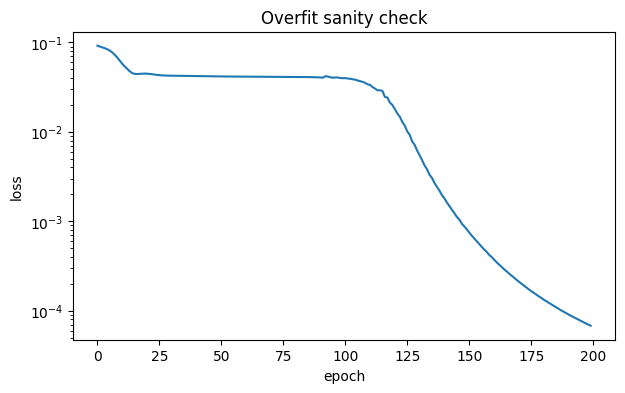

In [15]:

if CFG["overfit_debug_enabled"]:
    overfit_subset = Subset(ds_train, list(range(CFG["overfit_subset_size"])))
    overfit_loader = DataLoader(
        overfit_subset,
        batch_size=min(CFG["batch_size"], CFG["overfit_subset_size"]),
        shuffle=True, num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    overfit_model = GeoFNO2d(token_dim=CFG['token_dim'], branch_hidden=CFG['branch_hidden'], embed_dim=CFG['embed_dim'], source_aggregation=CFG['source_aggregation'], spreader_kernel=CFG['spreader_kernel'], spreader_layers=CFG['spreader_layers'], fno_width=CFG['fno_width'], fno_depth=CFG['fno_depth'], fno_modes_h=CFG['fno_modes_h'], fno_modes_w=CFG['fno_modes_w'], fno_padding=CFG['fno_padding'], H=H, W=W).to(device)
    overfit_optimizer = torch.optim.AdamW(
        overfit_model.parameters(), lr=CFG["overfit_lr"], weight_decay=0.0,
    )
    overfit_criterion = nn.MSELoss()
    overfit_scaler = None

    overfit_history = []
    for epoch in range(1, CFG["overfit_epochs"] + 1):
        loss = train_one_epoch(
            overfit_model, overfit_loader, overfit_optimizer,
            overfit_criterion, device, scaler=overfit_scaler,
        )
        overfit_history.append(loss)
        if epoch == 1 or epoch % 20 == 0 or epoch == CFG["overfit_epochs"]:
            print(f"[overfit] epoch {epoch:03d} | loss={loss:.6f}")

    plt.figure(figsize=(7, 4))
    plt.plot(overfit_history)
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.yscale("log")
    plt.title("Overfit sanity check")
    plt.show()

    del overfit_model, overfit_optimizer, overfit_scaler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print("overfit debug block is disabled")

## 9. Полное обучение

In [16]:
model = GeoFNO2d(token_dim=CFG['token_dim'], branch_hidden=CFG['branch_hidden'], embed_dim=CFG['embed_dim'], source_aggregation=CFG['source_aggregation'], spreader_kernel=CFG['spreader_kernel'], spreader_layers=CFG['spreader_layers'], fno_width=CFG['fno_width'], fno_depth=CFG['fno_depth'], fno_modes_h=CFG['fno_modes_h'], fno_modes_w=CFG['fno_modes_w'], fno_padding=CFG['fno_padding'], H=H, W=W).to(device)

print(f"GeoFNO params: {sum(p.numel() for p in model.parameters()):,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min",
    factor=CFG["scheduler_factor"], patience=CFG["scheduler_patience"],
    min_lr=CFG["min_lr"],
)

use_amp = False
scaler = None

RUN_DIR = Path("/workspace/reference_points") / CFG["run_name"]
RUN_DIR.mkdir(parents=True, exist_ok=True)

best_val = float("inf")
best_epoch = -1
best_ckpt_path = RUN_DIR / "geo_fno_best.pt"

train_history = []
val_history = []
lr_history = []
epochs_no_improve = 0

t0 = time.time()
for epoch in range(1, CFG["epochs"] + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler=scaler)
    val_loss = eval_loss(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    train_history.append(train_loss)
    val_history.append(val_loss)
    lr_history.append(current_lr)

    print(f"epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | lr={current_lr:.6e}")

    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "stats": stats,
                "config": CFG,
                "best_epoch": best_epoch,
                "best_val": best_val,
            },
            best_ckpt_path,
        )
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= CFG["patience"]:
        print("early stopping")
        break
t1 = time.time()
print("training time sec:", t1 - t0)
print("best_epoch:", best_epoch)
print("best_val:", best_val)

GeoFNO params: 169,990,161
epoch 001 | train_loss=0.042355 | val_loss=0.041922 | lr=1.000000e-03
epoch 002 | train_loss=0.026851 | val_loss=0.020296 | lr=1.000000e-03
epoch 003 | train_loss=0.016825 | val_loss=0.017012 | lr=1.000000e-03
epoch 004 | train_loss=0.012127 | val_loss=0.015652 | lr=1.000000e-03
epoch 005 | train_loss=0.008850 | val_loss=0.015220 | lr=1.000000e-03
epoch 006 | train_loss=0.006561 | val_loss=0.015121 | lr=1.000000e-03
epoch 007 | train_loss=0.005005 | val_loss=0.015112 | lr=1.000000e-03
epoch 008 | train_loss=0.003949 | val_loss=0.015165 | lr=1.000000e-03
epoch 009 | train_loss=0.003214 | val_loss=0.015185 | lr=1.000000e-03
epoch 010 | train_loss=0.002730 | val_loss=0.015018 | lr=1.000000e-03
epoch 011 | train_loss=0.002373 | val_loss=0.015099 | lr=1.000000e-03
epoch 012 | train_loss=0.002084 | val_loss=0.014910 | lr=1.000000e-03
epoch 013 | train_loss=0.001856 | val_loss=0.015009 | lr=1.000000e-03
epoch 014 | train_loss=0.001674 | val_loss=0.014981 | lr=1.0000

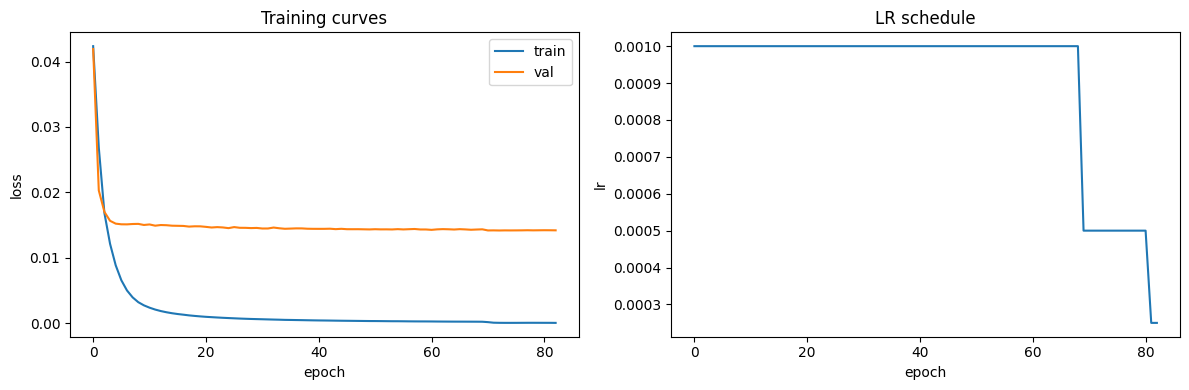

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(train_history, label="train")
ax[0].plot(val_history, label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[0].set_title("Training curves"); ax[0].legend()

ax[1].plot(lr_history)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("lr")
ax[1].set_title("LR schedule")
plt.tight_layout()
plt.show()

## 10. Best checkpoint evaluation

In [18]:
best_ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(best_ckpt["model_state_dict"])
model.eval()

train_metrics = evaluate_dataset(model, ds_train, device, stats["c_min"], stats["c_max"])
val_metrics = evaluate_dataset(model, ds_val, device, stats["c_min"], stats["c_max"])
test_metrics = evaluate_dataset(model, ds_test, device, stats["c_min"], stats["c_max"])

train_summary = summarize_metrics(train_metrics)
val_summary = summarize_metrics(val_metrics)
test_summary = summarize_metrics(test_metrics)

print("TRAIN SUMMARY")
print(json.dumps(train_summary, ensure_ascii=False, indent=2))
print("\nVAL SUMMARY")
print(json.dumps(val_summary, ensure_ascii=False, indent=2))
print("\nTEST SUMMARY")
print(json.dumps(test_summary, ensure_ascii=False, indent=2))

TRAIN SUMMARY
{
  "mse_mean": 0.4882102774900775,
  "mse_std": 0.1477704391175573,
  "rmse_mean": 0.6912075988515731,
  "rmse_std": 0.1021877336339957,
  "relative_l2_mean": 0.0004634442206447749,
  "relative_l2_std": 6.945347410792866e-05,
  "psnr_mean": 49.064712638057486,
  "psnr_std": 1.2564977582248469
}

VAL SUMMARY
{
  "mse_mean": 133.63929989433288,
  "mse_std": 96.02080395124459,
  "rmse_mean": 10.838711370706559,
  "rmse_std": 4.020153695983098,
  "relative_l2_mean": 0.007261619736906141,
  "relative_l2_std": 0.0026860357377693706,
  "psnr_mean": 25.697358103355022,
  "psnr_std": 3.3950096096789566
}

TEST SUMMARY
{
  "mse_mean": 339.30109745025635,
  "mse_std": 184.416766886263,
  "rmse_mean": 17.707224402427673,
  "rmse_std": 5.074968260694126,
  "relative_l2_mean": 0.011867911073495633,
  "relative_l2_std": 0.0034001317991473956,
  "psnr_mean": 21.186353428056773,
  "psnr_std": 2.6454042485073543
}


### 10.1 Geometry invariance на обученной модели

In [19]:
print("On TRAINED model:")
geom_invariance_test(model, ds_test, device, perm_axis="receiver", perm_kind="shift", k=4)
geom_invariance_test(model, ds_test, device, perm_axis="receiver", perm_kind="shift", k=37)
geom_invariance_test(model, ds_test, device, perm_axis="receiver", perm_kind="random")
geom_invariance_test(model, ds_test, device, perm_axis="source",   perm_kind="shift", k=3)
geom_invariance_test(model, ds_test, device, perm_axis="source",   perm_kind="random")

On TRAINED model:
[geom inv / receiver / shift, k=4]  max |y0 - y1| = 0.000e+00, rel = 0.000e+00
[geom inv / receiver / shift, k=37]  max |y0 - y1| = 0.000e+00, rel = 0.000e+00
[geom inv / receiver / random, k=4]  max |y0 - y1| = 0.000e+00, rel = 0.000e+00
[geom inv / source / shift, k=3]  max |y0 - y1| = 3.167e-04, rel = 4.169e-04
[geom inv / source / random, k=4]  max |y0 - y1| = 2.058e-04, rel = 2.710e-04


(0.00020582973957061768, 0.0002709599758814004)

## 11. Визуализация на test

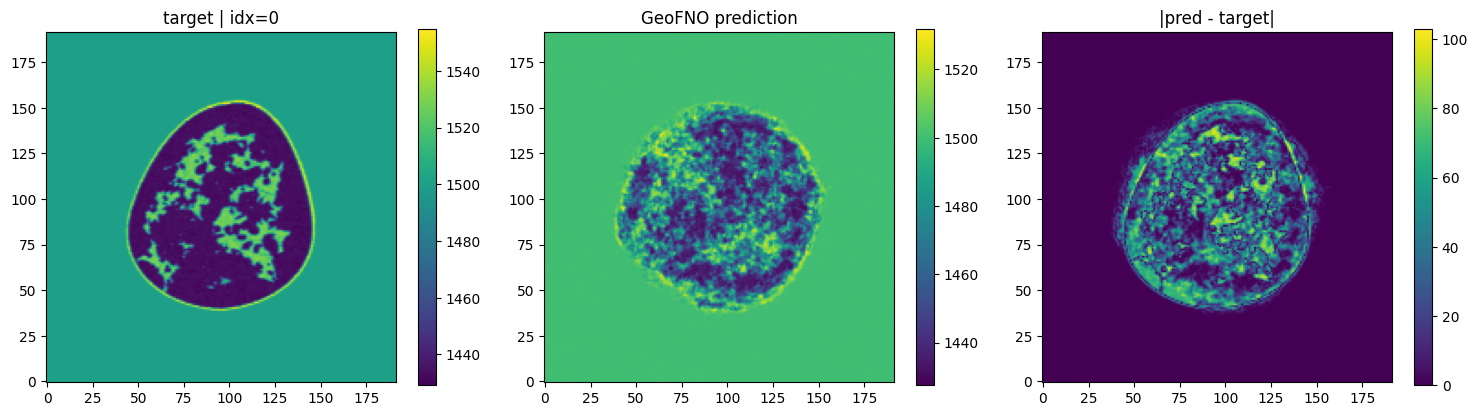

/workspace/usct_dataset_v2/test/sample_00000.npz


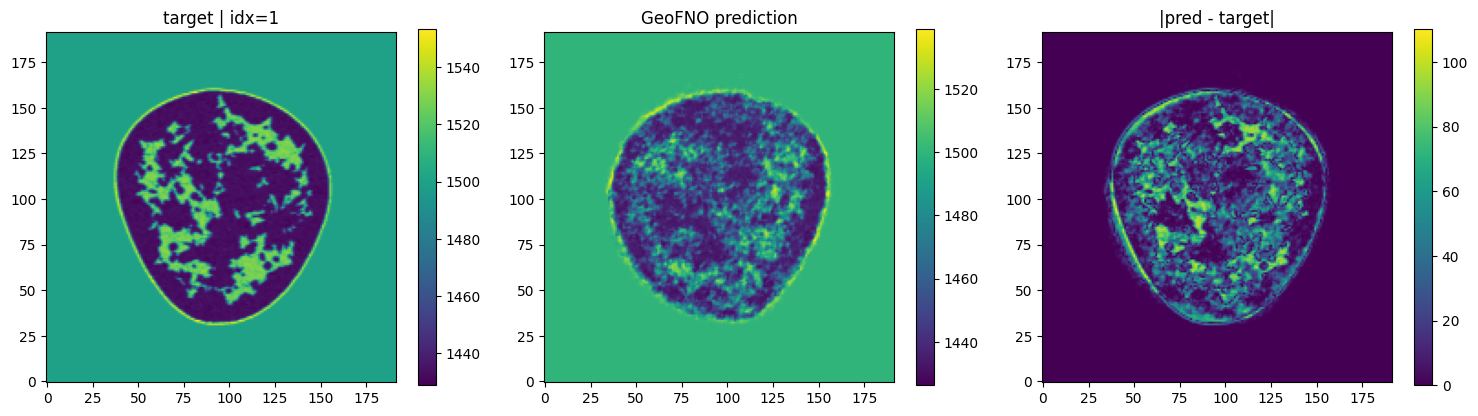

/workspace/usct_dataset_v2/test/sample_00001.npz


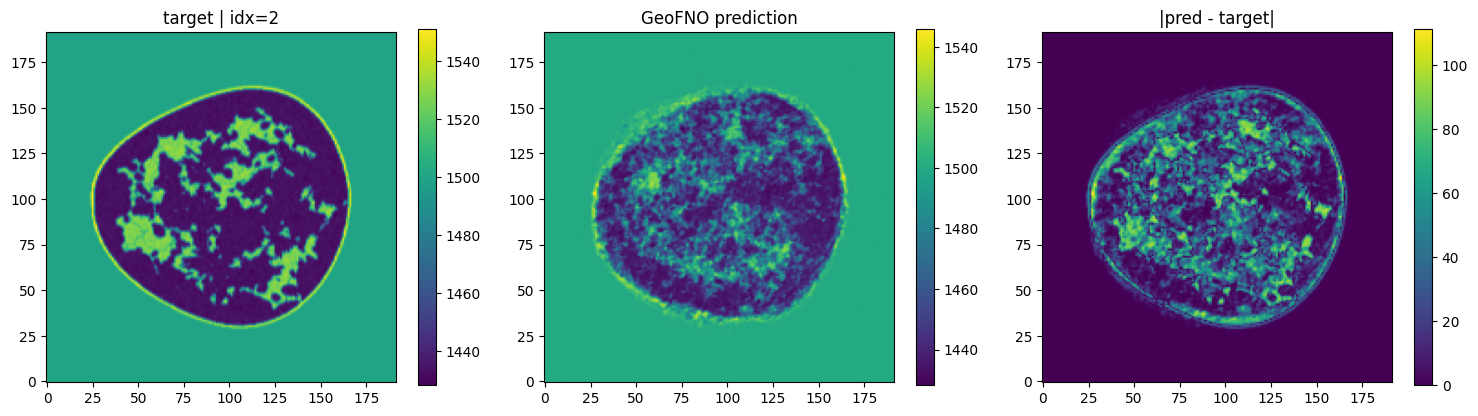

/workspace/usct_dataset_v2/test/sample_00002.npz


In [20]:
@torch.no_grad()
def show_prediction(model, dataset, idx, device, c_min, c_max):
    x, c, src_n, rcv_n, rcv_p, meta = dataset[idx]
    x      = x.unsqueeze(0).to(device)
    src_n  = src_n.unsqueeze(0).to(device)
    rcv_n  = rcv_n.unsqueeze(0).to(device)
    rcv_p  = rcv_p.unsqueeze(0).to(device)
    pred = model(x, src_n, rcv_n, rcv_p)[0, 0].cpu().numpy()
    pred = np.clip(pred, -1.0, 1.0)
    target = c[0].numpy()
    pred_phys = denorm_c_from_minus1_1(pred, c_min, c_max)
    target_phys = denorm_c_from_minus1_1(target, c_min, c_max)
    err = np.abs(pred_phys - target_phys)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    im0 = ax[0].imshow(target_phys, origin="lower")
    ax[0].set_title(f"target | idx={idx}"); plt.colorbar(im0, ax=ax[0])
    im1 = ax[1].imshow(pred_phys, origin="lower")
    ax[1].set_title("GeoFNO prediction"); plt.colorbar(im1, ax=ax[1])
    im2 = ax[2].imshow(err, origin="lower")
    ax[2].set_title("|pred - target|"); plt.colorbar(im2, ax=ax[2])
    plt.tight_layout()
    plt.show()
    print(meta["path"])

for idx in [0, 1, 2]:
    show_prediction(model, ds_test, idx, device, stats["c_min"], stats["c_max"])

## 12. Save artifacts

In [21]:
with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "config": CFG,
            "stats": stats,
            "S": int(S), "R": int(R),
            "H": int(H), "W": int(W),
            "dx": [float(v) for v in dx],
            "freq_hz": float(freq_hz),
            "best_epoch": int(best_epoch),
            "best_val": float(best_val),
            "num_params": int(sum(p.numel() for p in model.parameters())),
        },
        f, ensure_ascii=False, indent=2,
    )

for name, payload in [
    ("train_summary.json", train_summary),
    ("val_summary.json",   val_summary),
    ("test_summary.json",  test_summary),
    ("train_metrics.json", train_metrics),
    ("val_metrics.json",   val_metrics),
    ("test_metrics.json",  test_metrics),
]:
    with open(RUN_DIR / name, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

np.savez_compressed(
    RUN_DIR / "loss_history.npz",
    train_loss=np.array(train_history, dtype=np.float32),
    val_loss=np.array(val_history, dtype=np.float32),
    lr=np.array(lr_history, dtype=np.float32),
)
print("saved GeoFNO artifacts to:", RUN_DIR)

saved GeoFNO artifacts to: /workspace/reference_points/geo_fno_v1


Text(0.5, 1.0, 'Test RMSE distribution (mean=17.71)')

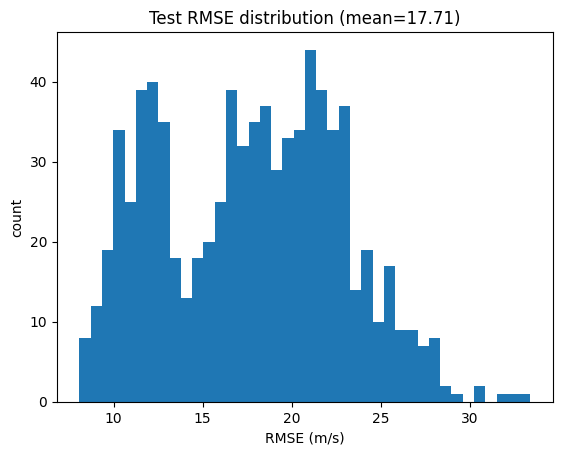

In [22]:
# Гистограмма test errors
import matplotlib.pyplot as plt
test_rmses = [m["rmse"] for m in test_metrics]
plt.hist(test_rmses, bins=40)
plt.xlabel("RMSE (m/s)"); plt.ylabel("count")
plt.title(f"Test RMSE distribution (mean={np.mean(test_rmses):.2f})")


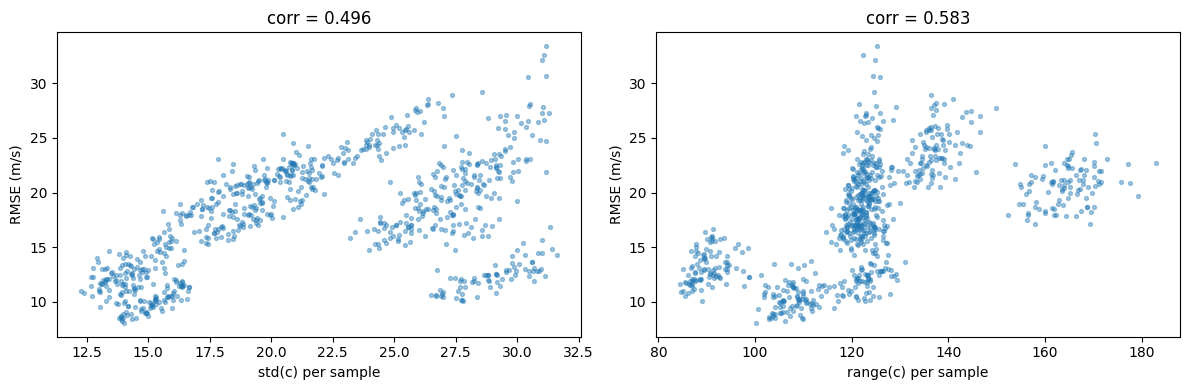

In [23]:
import numpy as np

c_stds, c_ranges, rmses = [], [], []
for m in test_metrics:
    d = np.load(m["path"])
    c = d["c"].astype(np.float32)
    c_stds.append(float(c.std()))
    c_ranges.append(float(c.max() - c.min()))
    rmses.append(m["rmse"])

c_stds = np.array(c_stds); c_ranges = np.array(c_ranges); rmses = np.array(rmses)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(c_stds, rmses, s=8, alpha=0.4)
ax[0].set_xlabel("std(c) per sample"); ax[0].set_ylabel("RMSE (m/s)")
ax[0].set_title(f"corr = {np.corrcoef(c_stds, rmses)[0,1]:.3f}")

ax[1].scatter(c_ranges, rmses, s=8, alpha=0.4)
ax[1].set_xlabel("range(c) per sample"); ax[1].set_ylabel("RMSE (m/s)")
ax[1].set_title(f"corr = {np.corrcoef(c_ranges, rmses)[0,1]:.3f}")
plt.tight_layout()


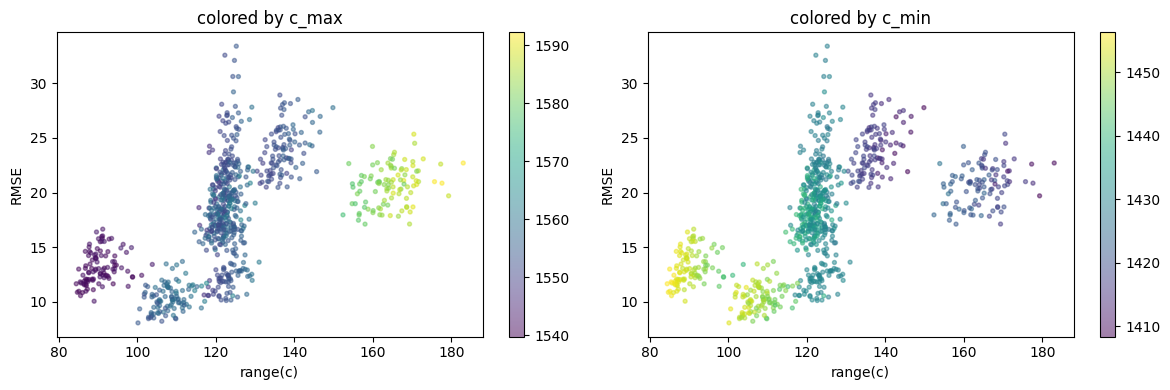

In [24]:
c_mins, c_maxs = [], []
for m in test_metrics:
    d = np.load(m["path"])
    c = d["c"].astype(np.float32)
    c_mins.append(float(c.min()))
    c_maxs.append(float(c.max()))
c_mins = np.array(c_mins); c_maxs = np.array(c_maxs)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sc0 = ax[0].scatter(c_ranges, rmses, c=c_maxs, s=8, alpha=0.5, cmap="viridis")
ax[0].set_xlabel("range(c)"); ax[0].set_ylabel("RMSE")
ax[0].set_title("colored by c_max")
plt.colorbar(sc0, ax=ax[0])

sc1 = ax[1].scatter(c_ranges, rmses, c=c_mins, s=8, alpha=0.5, cmap="viridis")
ax[1].set_xlabel("range(c)"); ax[1].set_ylabel("RMSE")
ax[1].set_title("colored by c_min")
plt.colorbar(sc1, ax=ax[1])
plt.tight_layout()


Text(0.5, 1.0, 'Distribution of c-range across splits')

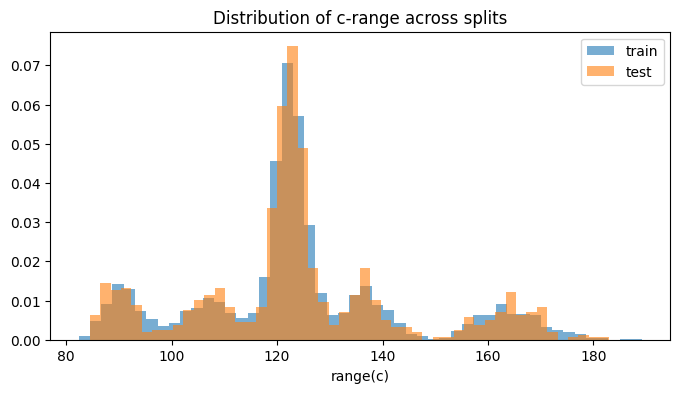

In [25]:
# то же самое для train_metrics
c_ranges_train = []
for m in train_metrics:
    d = np.load(m["path"])
    c = d["c"].astype(np.float32)
    c_ranges_train.append(float(c.max() - c.min()))

plt.figure(figsize=(8, 4))
plt.hist(c_ranges_train, bins=50, alpha=0.6, label="train", density=True)
plt.hist(c_ranges, bins=50, alpha=0.6, label="test", density=True)
plt.xlabel("range(c)"); plt.legend()
plt.title("Distribution of c-range across splits")


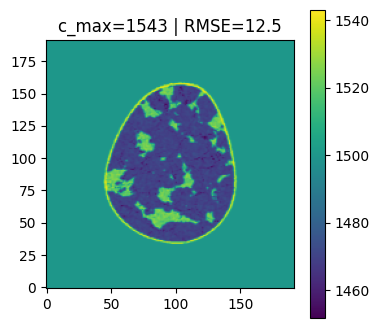

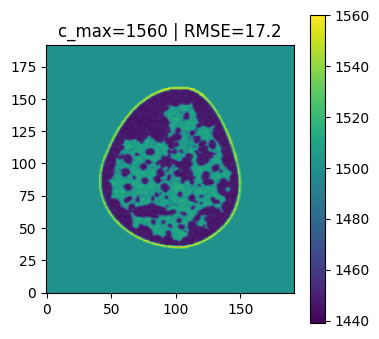

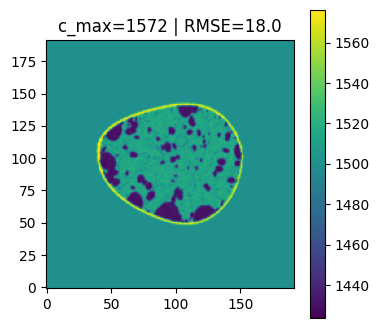

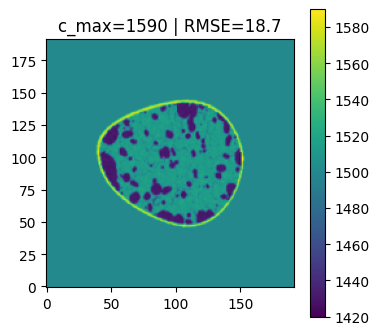

In [26]:
# 4 примера из 4 разных регионов c_max
for c_max_target in [1543, 1560, 1572, 1590]:
    idx = int(np.argmin(np.abs(c_maxs - c_max_target)))
    d = np.load(test_metrics[idx]["path"])
    plt.figure(figsize=(4,4))
    plt.imshow(d["c"], origin="lower"); plt.colorbar()
    plt.title(f"c_max={c_max_target} | RMSE={test_metrics[idx]['rmse']:.1f}")
    plt.show()
